#  Predicting Airline Passenger Satisfaction — GPU Starter Notebook

**Goal:** predict whether a passenger was *satisfied* (`True`) or *neutral/dissatisfied* (`False`) from flight details and survey ratings.

**Pipeline in this notebook**
1. Setup & GPU check
2. Load data & quick audit
3. EDA (target, numeric, categorical, ratings, correlations)
4. Preprocessing & feature engineering
5. Baselines (Logistic Regression, default XGBoost on GPU)
6. **Optuna** hyper-parameter search (XGBoost, GPU)
7. 5-fold stratified CV with tuned XGBoost + CatBoost (GPU)
8. Blend, threshold tuning, evaluation, feature importance
9. Submission file

>  Turn on a **GPU accelerator** in Kaggle (*Settings → Accelerator*). The notebook also runs on CPU, just slower.

## 1. Setup

In [1]:
import os, glob, shutil, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             confusion_matrix, classification_report, roc_curve)

import xgboost as xgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid", palette="deep")

# ---- Global config (change here) ----
SEED     = 42
N_FOLDS  = 5
N_TRIALS = 30          # Optuna trials (raise to 60-100 for a better search)
TARGET   = "satisfaction"
ID_COL   = "id"

# Use the GPU if nvidia-smi exists, otherwise fall back to CPU
HAS_GPU = shutil.which("nvidia-smi") is not None
DEVICE  = "cuda" if HAS_GPU else "cpu"
print(f"xgboost {xgb.__version__} | optuna {optuna.__version__} | device = {DEVICE}")

xgboost 3.2.0 | optuna 4.9.0 | device = cuda


## 2. Load data & quick audit

In [2]:
# Auto-discover train/test files inside /kaggle/input (edit paths manually if needed)
def find_file(name):
    hits = glob.glob(f"/kaggle/input/**/{name}", recursive=True)
    return hits[0] if hits else None

train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e10/train.csv")
test  = pd.read_csv("/kaggle/input/competitions/playground-series-s6e10/test.csv")

print("train shape:", train.shape, "| test shape:", None if test is None else test.shape)
train.head()

train shape: (699635, 23) | test shape: (299844, 22)


,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,0,36,694,4,4,4,3,1,4,1,...,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
1,1,56,651,5,5,5,5,5,4,4,...,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,True
2,2,31,1371,3,4,2,5,3,3,3,...,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
3,3,10,1616,3,5,3,3,3,3,3,...,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,False
4,4,23,481,3,4,3,4,5,3,5,...,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,False


In [3]:
# Data types, memory and missing values
train.info()
missing = train.isna().sum()
print("\nColumns with missing values:\n", missing[missing > 0])
print("\nDuplicate rows (excluding id):", train.drop(columns=[ID_COL]).duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699635 entries, 0 to 699634
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 699635 non-null  int64  
 1   Age                                699635 non-null  int64  
 2   Flight Distance                    699635 non-null  int64  
 3   Inflight wifi service              699635 non-null  int64  
 4   Departure/Arrival time convenient  699635 non-null  int64  
 5   Ease of Online booking             699635 non-null  int64  
 6   Gate location                      699635 non-null  int64  
 7   Food and drink                     699635 non-null  int64  
 8   Online boarding                    699635 non-null  int64  
 9   Seat comfort                       699635 non-null  int64  
 10  Inflight entertainment             699635 non-null  int64  
 11  On-board service                   6996

## 3. Exploratory Data Analysis

### 3.1 Target distribution
The classes are only mildly imbalanced (~55 / 45), so plain accuracy and AUC are both fine metrics — no resampling needed.

satisfaction
False    389296
True     310339
Name: count, dtype: int64 

 satisfaction
False    0.556
True     0.444
Name: count, dtype: float64


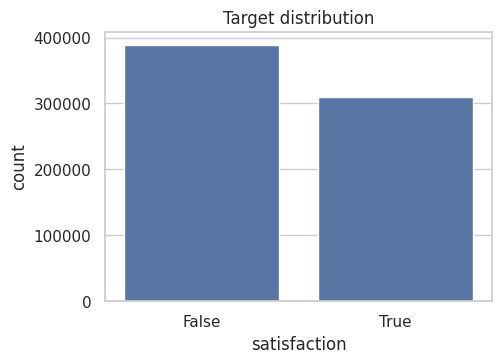

In [4]:
counts = train[TARGET].value_counts()
print(counts, "\n\n", (counts / len(train)).round(3))

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.countplot(x=TARGET, data=train, ax=ax)
ax.set_title("Target distribution")
plt.show()

### 3.2 Numeric features

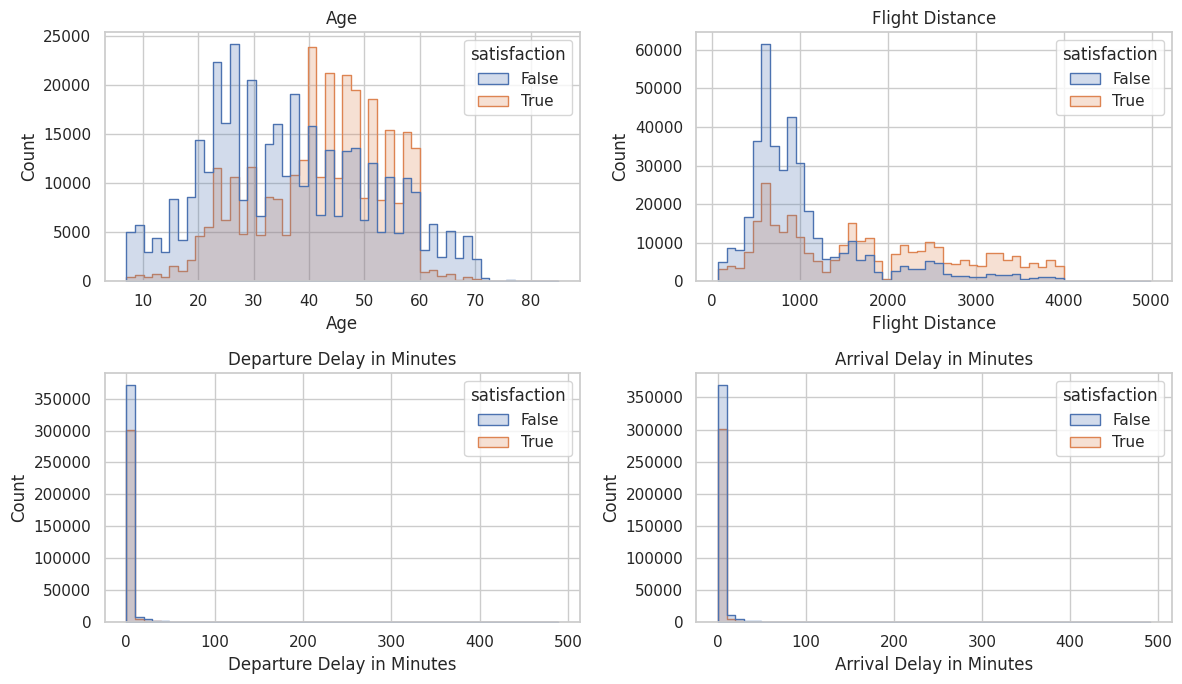

                               count         mean         std   min    25%  \
Age                         699635.0    39.001928   13.800943   7.0   27.0   
Flight Distance             699635.0  1353.778702  954.422566  67.0  631.0   
Departure Delay in Minutes  699635.0     1.176209    5.982187   0.0    0.0   
Arrival Delay in Minutes    699343.0     1.134280    5.749304   0.0    0.0   

                              50%     75%     max  
Age                          40.0    50.0    85.0  
Flight Distance             954.0  1814.0  4983.0  
Departure Delay in Minutes    0.0     0.0   489.0  
Arrival Delay in Minutes      0.0     0.0   491.0  


In [5]:
num_cols = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(data=train, x=c, hue=TARGET, bins=50, ax=ax, element="step")
    ax.set_title(c)
plt.tight_layout(); plt.show()

# Delays are heavily right-skewed -> a log transform helps linear models; trees don't care
print(train[num_cols].describe().T)

### 3.3 Categorical features vs. satisfaction
`Type of Travel`, `Class` and `Customer Type` usually carry a very strong signal.

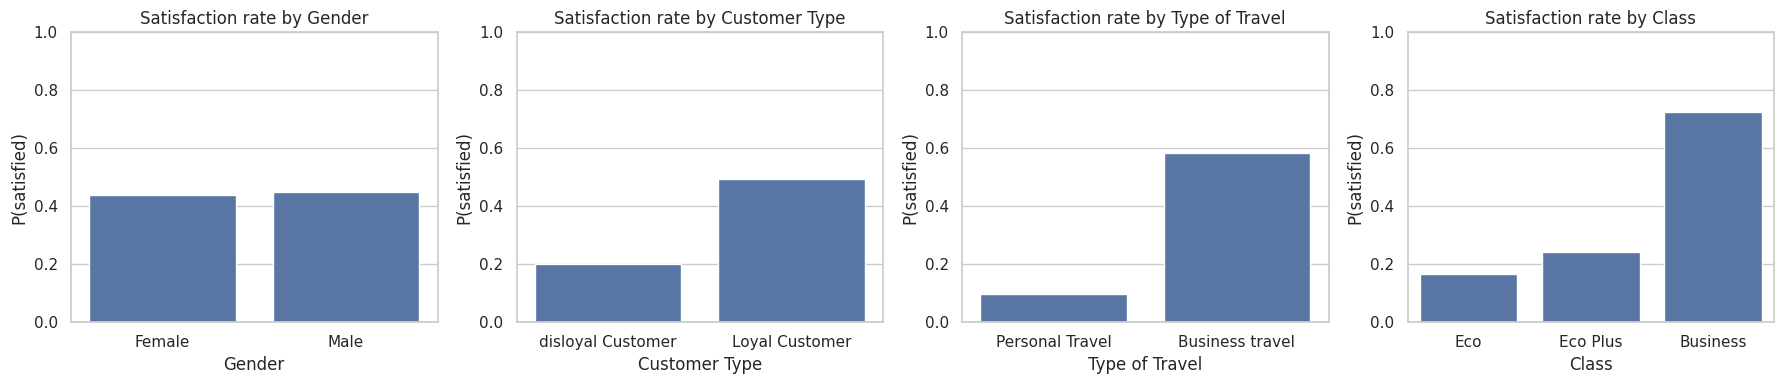

In [6]:
cat_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, cat_cols):
    rate = train.groupby(c)[TARGET].mean().sort_values()
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.set_title(f"Satisfaction rate by {c}"); ax.set_ylabel("P(satisfied)"); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

### 3.4 Survey rating features
Ratings are 0–5 where **0 = 'not applicable'**. We keep the zeros and later count them as a feature.

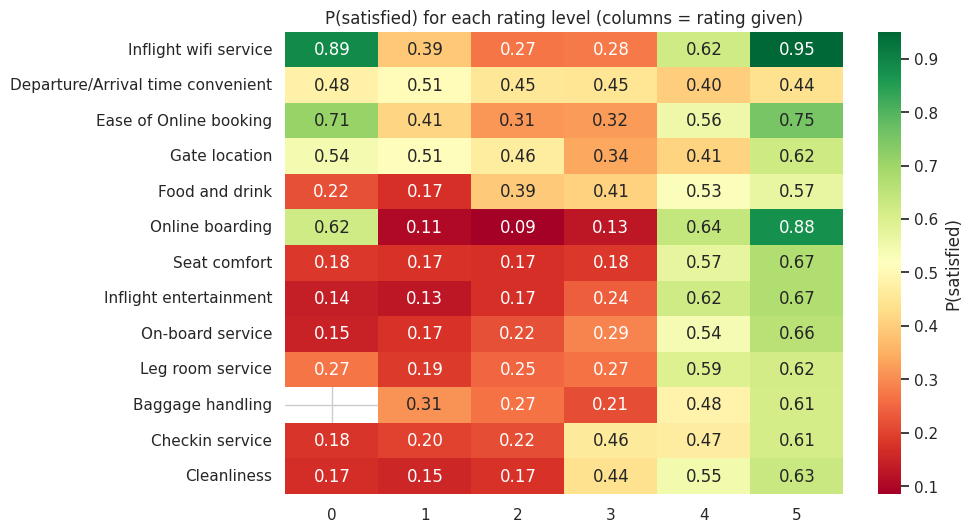

In [7]:
rating_cols = [
    "Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking",
    "Gate location", "Food and drink", "Online boarding", "Seat comfort",
    "Inflight entertainment", "On-board service", "Leg room service",
    "Baggage handling", "Checkin service", "Cleanliness",
]

# Mean satisfaction per rating value, per service
rate_tbl = pd.DataFrame({c: train.groupby(c)[TARGET].mean() for c in rating_cols}).T
plt.figure(figsize=(9, 6))
sns.heatmap(rate_tbl, annot=True, fmt=".2f", cmap="RdYlGn", cbar_kws={"label": "P(satisfied)"})
plt.title("P(satisfied) for each rating level (columns = rating given)")
plt.show()

### 3.5 Correlations

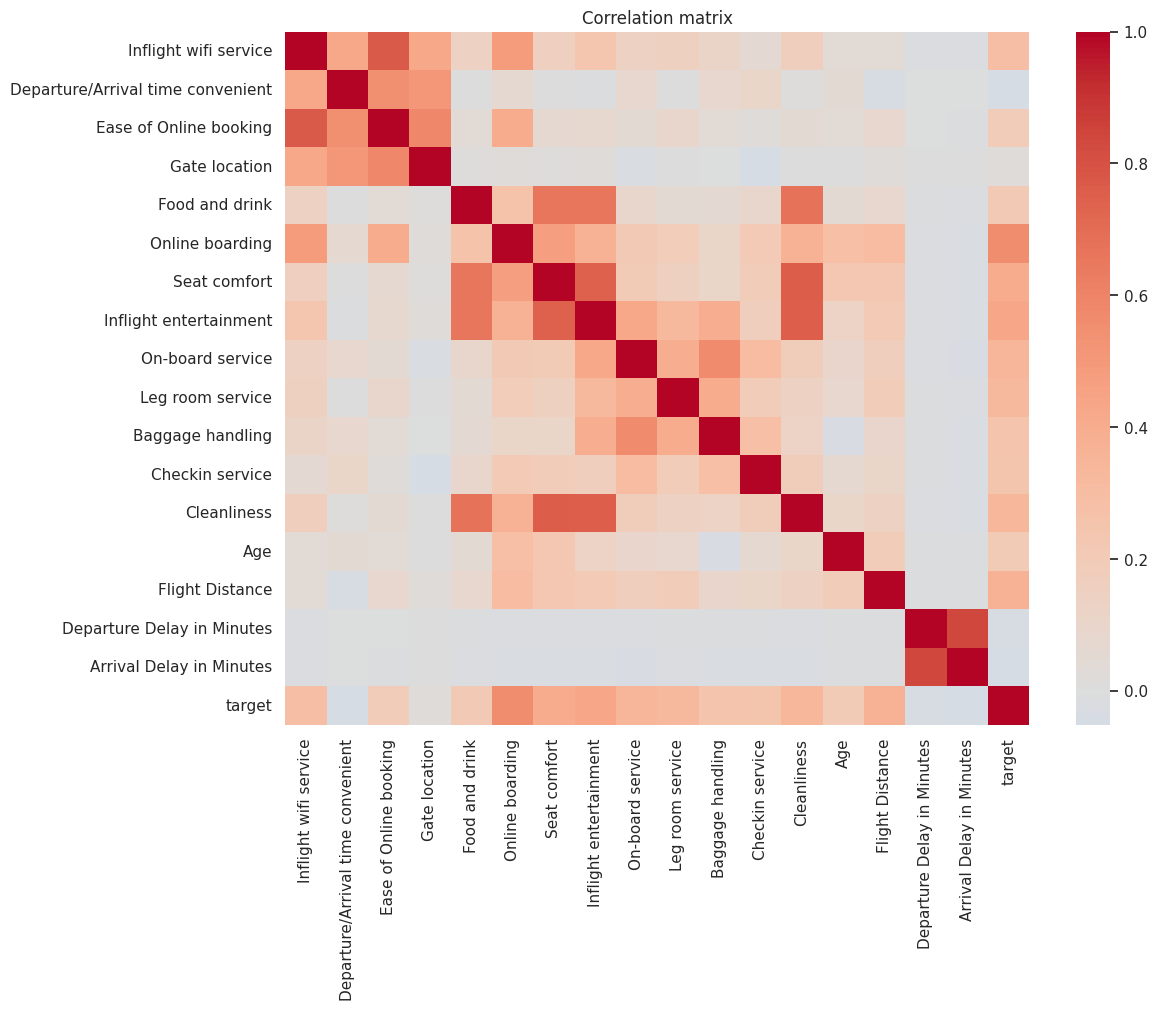

Top correlations with target:
Online boarding           0.560
Inflight entertainment    0.431
Seat comfort              0.401
Flight Distance           0.370
On-board service          0.347
Cleanliness               0.339
Leg room service          0.330
Inflight wifi service     0.291
Name: target, dtype: float64

Departure vs Arrival delay corr: 0.842


In [8]:
corr_df = train[rating_cols + num_cols].copy()
corr_df["target"] = train[TARGET].astype(int)
plt.figure(figsize=(12, 9))
sns.heatmap(corr_df.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation matrix")
plt.show()

print("Top correlations with target:")
print(corr_df.corr()["target"].drop("target").sort_values(ascending=False).round(3).head(8))
print("\nDeparture vs Arrival delay corr:",
      train["Departure Delay in Minutes"].corr(train["Arrival Delay in Minutes"]).round(3))

## 4. Preprocessing & feature engineering

Decisions based on the EDA:
- **Missing `Arrival Delay`** (≈0.04%): departure and arrival delay are ~0.97 correlated → fill with the departure delay of the same row (row-wise, so no leakage).
- **Binary columns** (`Gender`, `Customer Type`, `Type of Travel`) → 0/1.
- **`Class`** has a natural order (Eco < Eco Plus < Business) → ordinal encoding.
- **Engineered features:** aggregate rating stats, count of "not applicable" (0) ratings, delay difference, log distance, and grouped service scores.
- `id` is dropped (no signal).

All transformations are row-wise, so applying them to train and test separately is leakage-free.

In [9]:
comfort_cols = ["Seat comfort", "Leg room service", "Cleanliness", "Inflight entertainment", "Food and drink"]
digital_cols = ["Inflight wifi service", "Ease of Online booking", "Online boarding", "Checkin service"]

def preprocess(df):
    df = df.copy()

    # 1) Missing values: arrival delay ~ departure delay
    df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(df["Departure Delay in Minutes"])

    # 2) Encoding
    df["Gender"]         = (df["Gender"] == "Male").astype(int)
    df["Customer Type"]  = (df["Customer Type"] == "Loyal Customer").astype(int)
    df["Type of Travel"] = (df["Type of Travel"] == "Business travel").astype(int)
    df["Class"]          = df["Class"].map({"Eco": 0, "Eco Plus": 1, "Business": 2}).astype(int)

    # 3) Feature engineering
    r = df[rating_cols]
    df["rating_mean"]   = r.mean(axis=1)
    df["rating_std"]    = r.std(axis=1)
    df["rating_min"]    = r.min(axis=1)
    df["rating_max"]    = r.max(axis=1)
    df["n_zero_rating"] = (r == 0).sum(axis=1)          # 0 = "not applicable"
    df["n_low_rating"]  = ((r > 0) & (r <= 2)).sum(axis=1)
    df["n_high_rating"] = (r >= 4).sum(axis=1)
    df["comfort_score"] = df[comfort_cols].mean(axis=1)
    df["digital_score"] = df[digital_cols].mean(axis=1)

    df["delay_diff"]   = df["Arrival Delay in Minutes"] - df["Departure Delay in Minutes"]
    df["total_delay"]  = df["Arrival Delay in Minutes"] + df["Departure Delay in Minutes"]
    df["is_delayed"]   = (df["Arrival Delay in Minutes"] > 15).astype(int)
    df["log_distance"] = np.log1p(df["Flight Distance"])
    df["business_x_class"] = df["Type of Travel"] * df["Class"]
    return df

train_fe = preprocess(train)
test_fe  = preprocess(test) if test is not None else None

y = train_fe[TARGET].astype(int).values
FEATURES = [c for c in train_fe.columns if c not in [TARGET, ID_COL]]
X = train_fe[FEATURES]
X_test = test_fe[FEATURES] if test_fe is not None else None

print(f"{len(FEATURES)} features | X: {X.shape} | NaNs left: {X.isna().sum().sum()}")

35 features | X: (699635, 35) | NaNs left: 0


## 5. Baselines
A quick hold-out split (80/20, stratified) gives a reference score before tuning.

In [10]:
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

def evaluate(name, proba, y_true=y_val):
    acc = accuracy_score(y_true, proba > 0.5)
    auc = roc_auc_score(y_true, proba)
    print(f"{name:<28} accuracy = {acc:.5f} | AUC = {auc:.5f}")
    return acc, auc

# --- Baseline 1: scaled Logistic Regression (linear reference) ---
t0 = time.time()
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, n_jobs=-1))
lr.fit(X_tr, y_tr)
evaluate("Logistic Regression", lr.predict_proba(X_val)[:, 1])
print(f"   ({time.time()-t0:.1f}s)")

# --- Baseline 2: default XGBoost on GPU ---
t0 = time.time()
xgb_base = XGBClassifier(
    n_estimators=1000, learning_rate=0.1, tree_method="hist", device=DEVICE,
    eval_metric="auc", early_stopping_rounds=50, random_state=SEED,
)
xgb_base.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
evaluate("XGBoost (default, GPU)", xgb_base.predict_proba(X_val)[:, 1])
print(f"   best iteration = {xgb_base.best_iteration} ({time.time()-t0:.1f}s)")

Logistic Regression          accuracy = 0.89710 | AUC = 0.94014
   (4.6s)
XGBoost (default, GPU)       accuracy = 0.92385 | AUC = 0.95699
   best iteration = 268 (3.8s)


## 6. Hyper-parameter tuning with Optuna (XGBoost + GPU)

- **Why XGBoost?** The data is tabular, 700k rows, mostly ordinal ratings → gradient-boosted trees are the strongest and fastest family here, and `device="cuda"` makes each trial take seconds.
- Objective: validation **AUC** (smooth, threshold-free). Accuracy is reported later.
- Early stopping inside each trial finds the right number of trees automatically.

In [11]:
def objective(trial):
    params = dict(
        n_estimators          = 3000,
        learning_rate         = trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        max_depth             = trial.suggest_int("max_depth", 4, 10),
        min_child_weight      = trial.suggest_int("min_child_weight", 1, 20),
        subsample             = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree      = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        gamma                 = trial.suggest_float("gamma", 0.0, 5.0),
        reg_alpha             = trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda            = trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        max_bin               = trial.suggest_categorical("max_bin", [128, 256, 512]),
        tree_method="hist", device=DEVICE, eval_metric="auc",
        early_stopping_rounds=100, random_state=SEED,
    )
    model = XGBClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    trial.set_user_attr("best_iteration", int(model.best_iteration))
    return model.best_score          # validation AUC

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    study_name="xgb_airline",
)
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Done in {(time.time()-t0)/60:.1f} min")
print(f"Best AUC : {study.best_value:.5f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k:<18} {v}")

  0%|          | 0/30 [00:00<?, ?it/s]

Done in 2.9 min
Best AUC : 0.95800
Best params:
  learning_rate      0.020568440286238828
  max_depth          9
  min_child_weight   1
  subsample          0.9376349465736092
  colsample_bytree   0.6992450272667075
  gamma              1.2402816362062963
  reg_alpha          0.004531292986525189
  reg_lambda         3.698872463029457
  max_bin            512


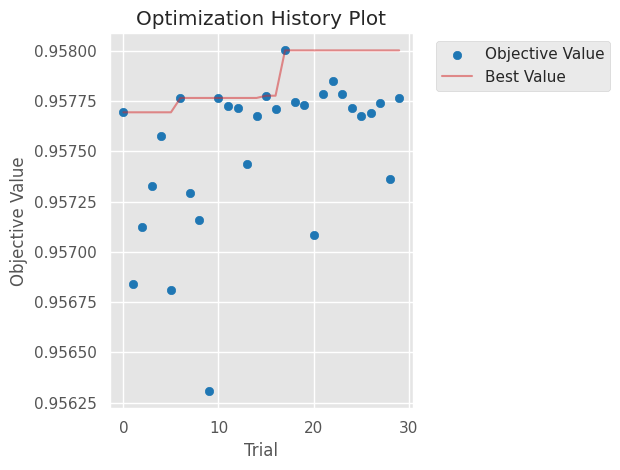

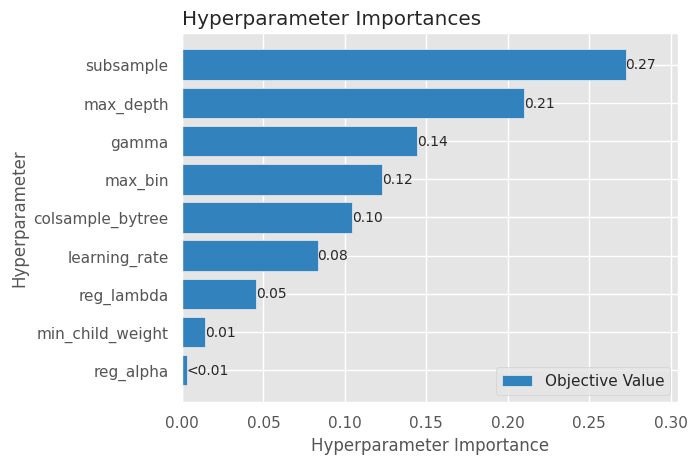

In [12]:
# Optuna diagnostics: optimisation history + hyper-parameter importance
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
plot_optimization_history(study); plt.show()
plot_param_importances(study); plt.show()

## 7. Final models: stratified K-fold CV
We train on **all** training data with 5-fold CV and keep:
- **OOF predictions** (honest estimate of generalisation + used for blending/threshold tuning)
- **Averaged test predictions** from the 5 fold models

Two GPU models are trained: tuned **XGBoost** and **CatBoost** (different algorithm → useful diversity for blending).

In [13]:
best_xgb_params = dict(
    **study.best_params,
    n_estimators=5000, tree_method="hist", device=DEVICE,
    eval_metric="auc", early_stopping_rounds=150, random_state=SEED,
)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_xgb = np.zeros(len(X))
pred_xgb = np.zeros(len(X_test)) if X_test is not None else None
xgb_models = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    m = XGBClassifier(**best_xgb_params)
    m.fit(X.iloc[tr_idx], y[tr_idx], eval_set=[(X.iloc[va_idx], y[va_idx])], verbose=False)
    oof_xgb[va_idx] = m.predict_proba(X.iloc[va_idx])[:, 1]
    if X_test is not None:
        pred_xgb += m.predict_proba(X_test)[:, 1] / N_FOLDS
    xgb_models.append(m)
    print(f"[XGB] fold {fold} | iters={m.best_iteration:>4} | "
          f"acc={accuracy_score(y[va_idx], oof_xgb[va_idx] > .5):.5f} | "
          f"auc={roc_auc_score(y[va_idx], oof_xgb[va_idx]):.5f}")

print(f"\nXGBoost OOF  accuracy={accuracy_score(y, oof_xgb > .5):.5f} | AUC={roc_auc_score(y, oof_xgb):.5f}")

[XGB] fold 1 | iters=1229 | acc=0.92574 | auc=0.95902
[XGB] fold 2 | iters= 723 | acc=0.92520 | auc=0.95764
[XGB] fold 3 | iters=1200 | acc=0.92788 | auc=0.95950
[XGB] fold 4 | iters=1599 | acc=0.92636 | auc=0.95881
[XGB] fold 5 | iters= 788 | acc=0.92574 | auc=0.95915

XGBoost OOF  accuracy=0.92618 | AUC=0.95882


In [14]:
cb_params = dict(
    iterations=3000, learning_rate=0.08, depth=8, l2_leaf_reg=3,
    eval_metric="AUC", loss_function="Logloss", early_stopping_rounds=150,
    random_seed=SEED, verbose=0,
    task_type="GPU" if HAS_GPU else "CPU",
)

oof_cb = np.zeros(len(X))
pred_cb = np.zeros(len(X_test)) if X_test is not None else None

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    m = CatBoostClassifier(**cb_params)
    m.fit(X.iloc[tr_idx], y[tr_idx], eval_set=(X.iloc[va_idx], y[va_idx]))
    oof_cb[va_idx] = m.predict_proba(X.iloc[va_idx])[:, 1]
    if X_test is not None:
        pred_cb += m.predict_proba(X_test)[:, 1] / N_FOLDS
    print(f"[CB ] fold {fold} | iters={m.get_best_iteration():>4} | "
          f"acc={accuracy_score(y[va_idx], oof_cb[va_idx] > .5):.5f} | "
          f"auc={roc_auc_score(y[va_idx], oof_cb[va_idx]):.5f}")

print(f"\nCatBoost OOF accuracy={accuracy_score(y, oof_cb > .5):.5f} | AUC={roc_auc_score(y, oof_cb):.5f}")

Default metric period is 5 because AUC is/are not implemented for GPU


[CB ] fold 1 | iters= 477 | acc=0.92561 | auc=0.95826


Default metric period is 5 because AUC is/are not implemented for GPU


[CB ] fold 2 | iters= 675 | acc=0.92536 | auc=0.95713


Default metric period is 5 because AUC is/are not implemented for GPU


[CB ] fold 3 | iters= 437 | acc=0.92689 | auc=0.95885


Default metric period is 5 because AUC is/are not implemented for GPU


[CB ] fold 4 | iters= 529 | acc=0.92603 | auc=0.95811


Default metric period is 5 because AUC is/are not implemented for GPU


[CB ] fold 5 | iters= 563 | acc=0.92544 | auc=0.95842

CatBoost OOF accuracy=0.92587 | AUC=0.95814


## 8. Blend, threshold tuning & evaluation

In [15]:
# Search the best blend weight on OOF predictions (simple 1-D grid)
best_w, best_auc = 0, 0
for w in np.linspace(0, 1, 21):
    auc = roc_auc_score(y, w * oof_xgb + (1 - w) * oof_cb)
    if auc > best_auc:
        best_w, best_auc = w, auc
print(f"Best blend: {best_w:.2f} * XGB + {1-best_w:.2f} * CatBoost | OOF AUC = {best_auc:.5f}")

oof_blend = best_w * oof_xgb + (1 - best_w) * oof_cb

# Tune the decision threshold for accuracy (usually ~0.5 for balanced-ish data)
thresholds = np.linspace(0.3, 0.7, 81)
accs = [accuracy_score(y, oof_blend > t) for t in thresholds]
best_t = thresholds[int(np.argmax(accs))]
print(f"Best threshold = {best_t:.3f} | OOF accuracy = {max(accs):.5f} (at 0.5: {accuracy_score(y, oof_blend > .5):.5f})")

Best blend: 0.80 * XGB + 0.20 * CatBoost | OOF AUC = 0.95887
Best threshold = 0.510 | OOF accuracy = 0.92627 (at 0.5: 0.92621)


                      precision    recall  f1-score   support

Neutral/Dissatisfied     0.9244    0.9448    0.9345    389296
           Satisfied     0.9287    0.9031    0.9157    310339

            accuracy                         0.9263    699635
           macro avg     0.9266    0.9239    0.9251    699635
        weighted avg     0.9263    0.9263    0.9262    699635



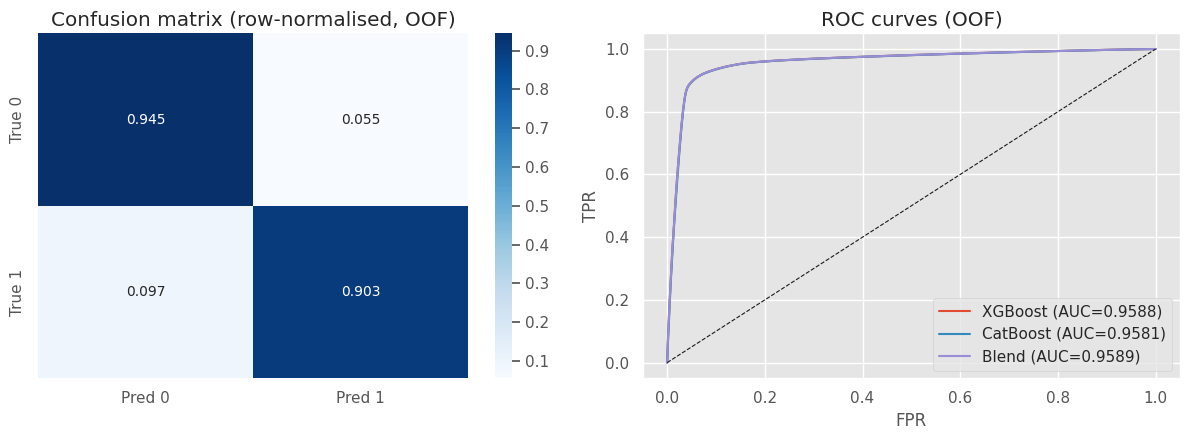

In [16]:
final_pred = (oof_blend > best_t).astype(int)
print(classification_report(y, final_pred, target_names=["Neutral/Dissatisfied", "Satisfied"], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(confusion_matrix(y, final_pred, normalize="true"), annot=True, fmt=".3f",
            cmap="Blues", ax=axes[0], xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
axes[0].set_title("Confusion matrix (row-normalised, OOF)")

for name, p in [("XGBoost", oof_xgb), ("CatBoost", oof_cb), ("Blend", oof_blend)]:
    fpr, tpr, _ = roc_curve(y, p)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y, p):.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].set_title("ROC curves (OOF)"); axes[1].legend()
plt.tight_layout(); plt.show()

### Feature importance
Average **gain** importance across the 5 XGBoost fold models.

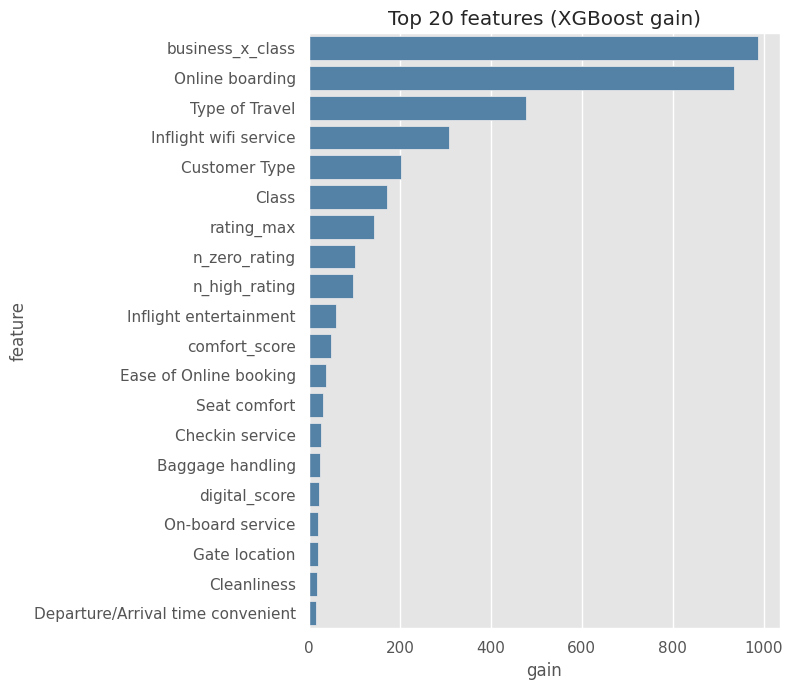

In [17]:
def fold_gain(model):
    score = model.get_booster().get_score(importance_type="gain")
    return [score.get(f, 0.0) for f in FEATURES]

imp = pd.DataFrame({
    "feature": FEATURES,
    "gain": np.mean([fold_gain(m) for m in xgb_models], axis=0),
}).sort_values("gain", ascending=False).head(20)

plt.figure(figsize=(8, 7))
sns.barplot(data=imp, y="feature", x="gain", color="steelblue")
plt.title("Top 20 features (XGBoost gain)")
plt.tight_layout(); plt.show()

## 9. Submission
Writes `submission.csv` with the blended **probability** of satisfaction.
If the competition expects hard labels, switch to the commented line (`True/False`).

In [18]:
if X_test is not None:
    test_blend = best_w * pred_xgb + (1 - best_w) * pred_cb
    sub = pd.DataFrame({ID_COL: test[ID_COL], TARGET: test_blend})          # probabilities
    # sub[TARGET] = (test_blend > best_t)                                    # hard True/False labels
    sub.to_csv("submission.csv", index=False)
    print(sub.shape); display(sub.head())
else:
    print("No test.csv found - skipping submission.")

(299844, 2)


,id,satisfaction
0,699635,0.243529
1,699636,0.885254
2,699637,0.898013
3,699638,0.071549
4,699639,0.057992


## 10. Takeaways & ideas to go further
- **Ratings drive satisfaction**: online boarding, inflight entertainment, seat comfort, and `Type of Travel` / `Class` dominate; delays matter much less.
- Feature engineering gave small but consistent gains; tuned GBDTs are far ahead of the linear baseline, showing strong non-linear interactions.

**Next steps**
- Increase `N_TRIALS` (60–100) and also tune CatBoost / LightGBM with Optuna.
- Try target-encoding or treating ratings as categorical (CatBoost `cat_features`).
- Add a third model (LightGBM, or a small NN) and use a stacking meta-learner.
- Repeat CV with multiple seeds and average for a more stable score.

If this helped, please **upvote** 👍 and share your improvements in the comments!